## 🟡 Overview & Category Intelligence

- This section provides a high-level overview of groundwater conditions and category-wise insights.
It helps in understanding overall distribution, usage patterns, and risk variations.

##### pip install Libraries  
- pip install pandas plotly missingno 

##### Import Libraries

In [44]:
import pandas as pd 
import plotly.express as px
import missingno as msno
import plotly.graph_objects as go

##### Load Dataset

In [45]:
df = pd.read_csv("groundwater_ml_dataset_cleaned.csv")
df.head()

,state,district,annual_recharge,extractable_resource,annual_extraction,stage_of_development,category,extraction_ratio,utilization_rate,stress_level,risk_score,year
0,Himachal Pradesh,Himachal Pradesh,0.61,0.18,0.13,0.20,Safe,0.213115,0.722222,0.0020,0.374535,2024
1,Madhya Pradesh,Madhya Pradesh,27.00,1.68,0.17,7.04,Safe,0.006296,0.101190,0.0704,0.057075,2024
2,Andhra Pradesh,Alluri Sitharama Raju,43956.31,102516.48,2860.84,8890.60,Over Exploited,0.065084,0.027906,88.9060,17.818396,2024
3,Andhra Pradesh,Anakapalli,22443.69,38195.76,14423.44,6889.74,Over Exploited,0.642650,0.377619,68.8974,14.187588,2024
4,Andhra Pradesh,Ananthapuramu,40986.63,44150.14,1323.64,35512.65,Over Exploited,0.032294,0.029980,355.1265,71.050210,2024


##### Clean Column Names 

In [46]:
df.columns = df.columns.str.strip().str.lower()

##### Check Missing Values (Visual + Numeric)

- Numeric Check - shows missing data numerically 

In [47]:
print(df.isnull().sum())
print("Total Missing Values:", df.isnull().sum().sum())

state                   0
district                0
annual_recharge         0
extractable_resource    0
annual_extraction       0
stage_of_development    0
category                0
extraction_ratio        0
utilization_rate        0
stress_level            0
risk_score              0
year                    0
dtype: int64
Total Missing Values: 0


- Total Null Values 

In [48]:
df.isnull().sum().sum()

np.int64(0)

- Visual Check  - Shows missing data visually

<Axes: >

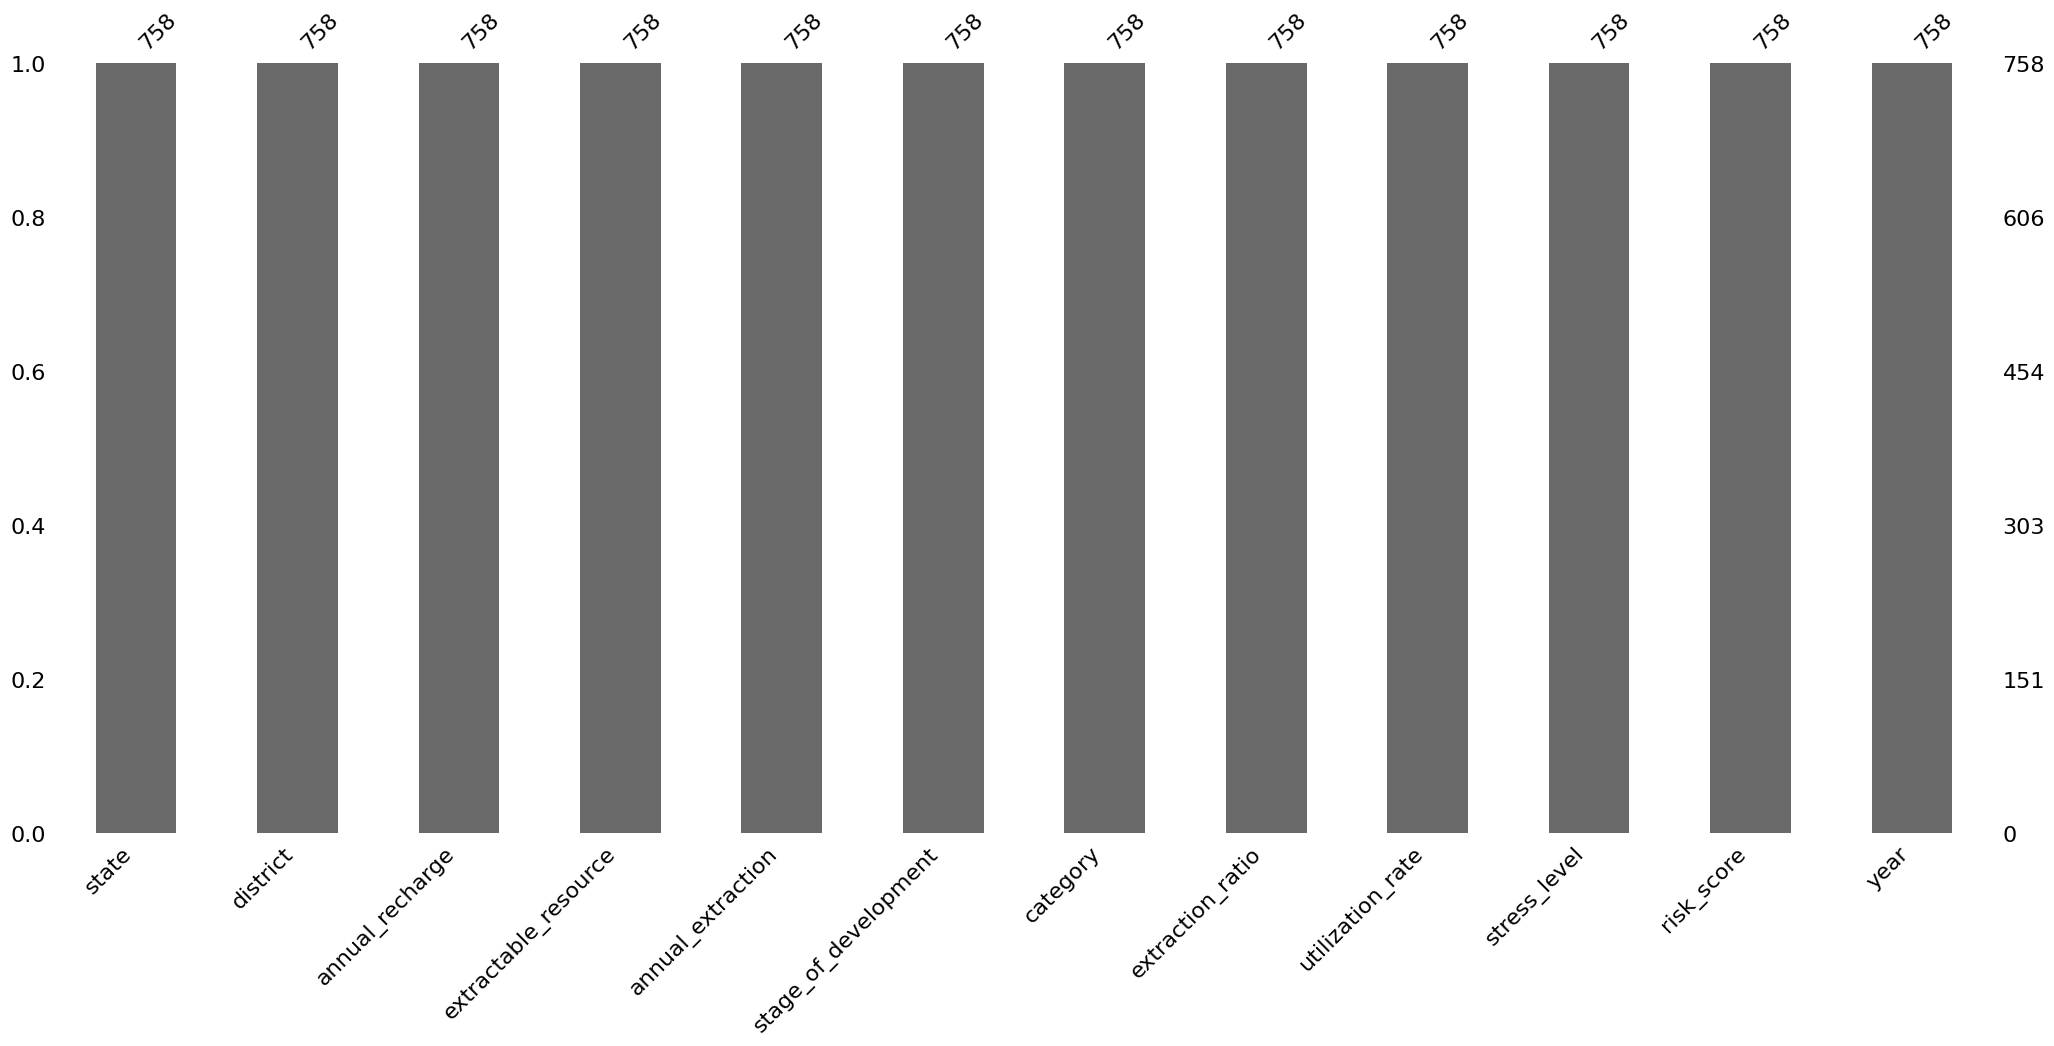

In [49]:
msno.bar(df)

##### Handle Missing Values

- Option 1: Drop Missing Values (if very few)

In [50]:
df.dropna(inplace=True)

##### Create Derived Column (Water Balance)
- To enhance analysis, a new feature called Water Balance is created by subtracting annual groundwater extraction from recharge.
This helps in identifying regions with water surplus (positive values) and water deficit (negative values), supporting sustainability analysis.
- NOTE: (We create a new column called Water Balance by subtracting annual extraction from annual recharge.
This helps identify whether a region has a water surplus or deficit.)

In [51]:
df['water_balance'] = df['annual_recharge'] - df['annual_extraction']
df.head()

,state,district,annual_recharge,extractable_resource,annual_extraction,stage_of_development,category,extraction_ratio,utilization_rate,stress_level,risk_score,year,water_balance
0,Himachal Pradesh,Himachal Pradesh,0.61,0.18,0.13,0.20,Safe,0.213115,0.722222,0.0020,0.374535,2024,0.48
1,Madhya Pradesh,Madhya Pradesh,27.00,1.68,0.17,7.04,Safe,0.006296,0.101190,0.0704,0.057075,2024,26.83
2,Andhra Pradesh,Alluri Sitharama Raju,43956.31,102516.48,2860.84,8890.60,Over Exploited,0.065084,0.027906,88.9060,17.818396,2024,41095.47
3,Andhra Pradesh,Anakapalli,22443.69,38195.76,14423.44,6889.74,Over Exploited,0.642650,0.377619,68.8974,14.187588,2024,8020.25
4,Andhra Pradesh,Ananthapuramu,40986.63,44150.14,1323.64,35512.65,Over Exploited,0.032294,0.029980,355.1265,71.050210,2024,39662.99


In [52]:
df[['annual_recharge', 'annual_extraction', 'water_balance']].head()   #Print Specific Columns we need only to check

,annual_recharge,annual_extraction,water_balance
0,0.61,0.13,0.48
1,27.00,0.17,26.83
2,43956.31,2860.84,41095.47
3,22443.69,14423.44,8020.25
4,40986.63,1323.64,39662.99


##### Color Theme Adding
- To improve data visualization and user experience, a consistent and aesthetically pleasing color theme has been used.
Different color palettes are applied to distinguish categories, highlight variations, and make insights easier to interpret.

In [53]:
px.colors.sequential.Tealgrn

['rgb(176, 242, 188)',
 'rgb(137, 232, 172)',
 'rgb(103, 219, 165)',
 'rgb(76, 200, 163)',
 'rgb(56, 178, 163)',
 'rgb(44, 152, 160)',
 'rgb(37, 125, 152)']

### 1. Category Distribution (Pie Chart)
- This chart shows the distribution of groundwater categories across the dataset.
It helps identify which category (Safe, Critical, Over-exploited, etc.) is most common.


💡 Insight:

- A higher proportion of critical categories indicates groundwater stress.

In [54]:
fig1 = px.pie(
    df,
    names='category',
    title='Category Distribution',
    color_discrete_sequence=px.colors.sequential.Blugrn_r
)

fig1.update_layout(template='plotly_white', title_x=0.5)
fig1.show()

### 2 District Count per State

- This chart shows how many districts are present in each state 
in the dataset.

- It helps understand data distribution across states and 
which states have more regional coverage.

In [55]:
# Count districts per state
district_count = df.groupby('state')['district'].nunique().reset_index()
district_count.columns = ['state', 'district_count']

fig = px.treemap(
    district_count,
    path=['state'],
    values='district_count',
    title='District Count per State',
    color='district_count',
    color_continuous_scale=px.colors.sequential.Tealgrn
)

fig.update_layout(title_x=0.5)
fig.show()

#### code here

### 3. Avg Recharge vs Extraction

- This chart compares the average groundwater recharge and extraction across different categories.
It helps understand whether water usage is sustainable.

💡 Insight:

- Categories with higher extraction than recharge indicate unsustainable usage.

In [56]:
avg_values = df.groupby('category')[['annual_recharge', 'annual_extraction']].mean().reset_index()

fig2 = px.bar(
    avg_values,
    x='category',
    y=['annual_recharge', 'annual_extraction'],
    barmode='group',
    title='Avg Recharge vs Extraction',
    color_discrete_sequence=px.colors.sequential.Blugrn_r
)

fig2.update_layout(template='plotly_white', title_x=0.5)
fig2.show()

### 4. Avg Risk Score per Category

- This chart shows the average risk score for each groundwater category.
It helps identify which category is most vulnerable.

💡 Insight:

- Higher risk scores indicate areas prone to groundwater depletion.

In [57]:
avg_risk = df.groupby('category')['risk_score'].mean().reset_index()

fig3 = px.bar(
    avg_risk,
    x='category',
    y='risk_score',
    color='risk_score',
    color_continuous_scale=px.colors.sequential.Blugrn,
    title='Average Risk Score'
)

fig3.update_layout(template='plotly_white', title_x=0.5)
fig3.show()

### 5. Stress Level Distribution

- This histogram shows the distribution of groundwater stress levels across all regions.


💡 Insight:

- A skew towards higher values indicates widespread groundwater stress.

In [58]:
fig4 = px.histogram(
    df,
    x='stress_level',
    nbins=25,
    title='Stress Level Distribution',
    color_discrete_sequence=px.colors.sequential.Blugrn_r
)

fig4.update_layout(template='plotly_white', title_x=0.5)
fig4.show()

### 6. Utilization Rate per Category


- This chart shows the average utilization rate across different categories.

- Each slice represents a category and its proportion of total utilization.

- It helps quickly identify which category has higher water usage pressure.

💡 Insight:

- Higher utilization rates indicate heavy dependence on groundwater.


In [59]:
avg_util = df.groupby('category')['utilization_rate'].mean().reset_index()

fig5 = px.pie(
    avg_util,
    names='category',
    values='utilization_rate',
    title='Utilization Rate',
    hole=0.5,  # makes it donut
    color='utilization_rate',
    color_discrete_sequence=px.colors.sequential.Blugrn_r
)

fig5.update_layout(template='plotly_white', title_x=0.5)
fig5.show()

### 7. Extraction Distribution (Box Plot)

- This box plot shows the spread and variability of groundwater extraction across categories.

💡 Insight:

- Wider spread indicates inconsistency in water usage.


In [60]:
fig6 = px.box(
    df,
    x='category',
    y='annual_extraction',
    color='category',
    color_discrete_sequence=px.colors.sequential.Tealgrn
    ,
    title='Extraction Distribution'
)

fig6.update_layout(template='plotly_white', title_x=0.5)
fig6.show()

 ### 8. Water Balance Distribution

- This graph shows the distribution of water balance across different regions.  
Water balance is calculated as the difference between groundwater recharge and extraction.

- A positive value indicates surplus water availability, while a negative value represents a deficit condition.
- This visualization helps in identifying areas facing groundwater stress and understanding overall sustainability patterns.

In [61]:
fig7 = px.histogram(
    df,
    x='water_balance',
    nbins=25,
    title='Water Balance Distribution',
    color_discrete_sequence=px.colors.sequential.Blugrn_r
)

fig7.update_layout(template='plotly_white', title_x=0.5)
fig7.show()

### 9. State-wise Category Heatmap
- 💡 Insight:

Helps identify which states are over-extracting groundwater in which category. Useful for policy targeting.

In [ ]:
heat_df = df.groupby(['state', 'category'])['annual_extraction'].mean().reset_index()

fig = px.density_heatmap(
    heat_df,
    x='state',
    y='category',
    z='annual_extraction',
    color_continuous_scale='Tealgrn',
    title='State-wise Category Heatmap (Avg Extraction)'
)

fig.update_layout(template='plotly_white', title_x=0.5)
fig.show()

### 10. Category Trend Over Years
- 💡 Insight:

Shows whether extraction is increasing or decreasing over time per category — helps detect long-term sustainability issues.

In [63]:
fig = px.bar(
     trend_df,
    x='year',
    y='annual_extraction',
    color='category',
    barmode='group',
    title='Category-wise Extraction Comparison Over Years',
    color_discrete_sequence=px.colors.sequential.Blugrn_r
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig.show()

### 11. Top District per Category (Winner View)
-💡 Insight:

Shows the most stressed district per category. This is useful for highlighting critical hotspots.

In [64]:
top_districts = df.loc[df.groupby('category')['annual_extraction'].idxmax()]

fig = px.bar(
    top_districts,
    x='category',
    y='annual_extraction',
    color='district',
    title='Top District per Category (Max Extraction)',
    color_discrete_sequence=px.colors.sequential.Blugrn_r
)

fig.update_layout(template='plotly_white', title_x=0.5)
fig.show() 

### 12 Groundwater Data Table (Simple View)
- 🔍 Description

- This is a clean and simple table visualization of groundwater data showing key indicators like:

      State & District
      Annual Recharge
      Annual Extraction
      Risk Score
      Stress Level

- It provides a quick overview of overall groundwater conditions without any filters or interactions.

In [ ]:

df = df.copy()

df = df.dropna(subset=['state', 'district'])

fig = go.Figure(data=[go.Table(
    header=dict(
        values=[
            'State',
            'District',
            'Annual Recharge',
            'Annual Extraction',
            'Risk Score',
            'Stress Level'
        ],
        fill_color='#023047',
        font=dict(color='white'),
        align='center'
    ),
    cells=dict(
        values=[
            df['state'].astype(str),
            df['district'].astype(str),
            df['annual_recharge'].round(2),
            df['annual_extraction'].round(2),
            df['risk_score'].round(2),
            df['stress_level'].astype(str)
        ],
        fill_color='#E0FBFC',
        align='center'
    )
)])

fig.update_layout(
    title="🌍 Groundwater Data Table",
    title_x=0.5,
    template="plotly_white"
)

fig.show()